### 1. Importing the libraries. Loading and preprocessing the dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# load the dataset
df=pd.read_csv('heart.csv')

In [3]:
print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [4]:
# Display the summary of the dataset
print("\nDataset Summary:")
print(df.info())


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [5]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 2. Feature Selection and Train-Test Split

In [6]:
# Split the dataset into features and target
X = df.drop('target', axis=1)
y = df['target']

In [7]:
# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (820, 13)
Testing set: (205, 13)


### 3. Decision Tree

In [9]:
# Train Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

In [10]:
# Visualize the Decision Tree and save it as an image
plt.figure(figsize=(200, 100))
plot_tree(dtree, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree")
plt.savefig("decision_tree.png")
plt.show()

In [11]:
# Print Tree Rules
tree_rules = export_text(dtree, feature_names=list(X.columns))
print(tree_rules)

|--- cp <= 0.50
|   |--- ca <= 0.50
|   |   |--- thal <= 2.50
|   |   |   |--- exang <= 0.50
|   |   |   |   |--- thalach <= 96.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- thalach >  96.50
|   |   |   |   |   |--- chol <= 316.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- chol >  316.50
|   |   |   |   |   |   |--- slope <= 1.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- slope >  1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |--- exang >  0.50
|   |   |   |   |--- thalach <= 146.00
|   |   |   |   |   |--- trestbps <= 115.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- trestbps >  115.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- thalach >  146.00
|   |   |   |   |   |--- oldpeak <= 0.80
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- oldpeak >  0.80
|   |   |   |   |   |   |--- restecg <= 0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- 

In [12]:
# Accuracy & Report
print("\nDecision Tree Test Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))


Decision Tree Test Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [13]:
# Check Overfitting
train_acc = dtree.score(X_train, y_train)
test_acc = dtree.score(X_test, y_test)
print(f"\nTrain Accuracy: {train_acc}, Test Accuracy: {test_acc}")



Train Accuracy: 1.0, Test Accuracy: 0.9853658536585366


In [14]:
# Limit tree depth to prevent overfitting
dtree_limited = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree_limited.fit(X_train, y_train)
print("\nDecision Tree (limited depth=5) Test Accuracy:", dtree_limited.score(X_test, y_test))


Decision Tree (limited depth=5) Test Accuracy: 0.8439024390243902


### 4. Random Forest

In [15]:
# Train Random Forest
rforest = RandomForestClassifier(n_estimators=100, random_state=42)
rforest.fit(X_train, y_train)
y_pred_rf = rforest.predict(X_test)

In [16]:
# Accuracy & Report
print("\nRandom Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Test Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [17]:
# Limit forest depth to prevent overfitting
rforest_limited = RandomForestClassifier(max_depth=5, random_state=42)
rforest_limited.fit(X_train, y_train)
print("\nRandom Forest (limited depth=5) Test Accuracy:", rforest_limited.score(X_test, y_test))


Random Forest (limited depth=5) Test Accuracy: 0.8731707317073171


### 5. Feature Importance

In [18]:
# Feature Importance
importances = rforest.feature_importances_
features = X.columns
ft_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

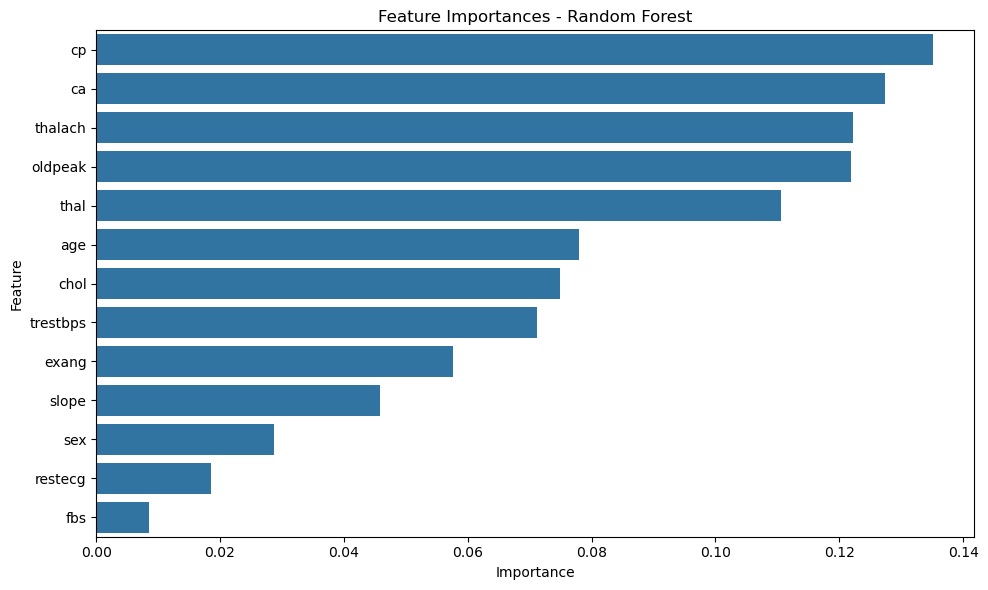

In [19]:
# Plot Feature Importances and save the it as an image
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=ft_imp_df)
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.savefig("Feature Importances.png")
plt.show()

### 6. Cross Validation

In [20]:
# Cross-Validation
cv_dt = cross_val_score(dtree, X, y, cv=5)
cv_rf = cross_val_score(rforest, X, y, cv=5)

print(f"\nCross-Validation Accuracy (Decision Tree): {cv_dt.mean():.2f}")
print(f"Cross-Validation Accuracy (Random Forest): {cv_rf.mean():.2f}")


Cross-Validation Accuracy (Decision Tree): 1.00
Cross-Validation Accuracy (Random Forest): 1.00
